# Clustering Pipeline Example

This notebook demonstrates the full **time series clustering pipeline** integrated into the ThreeWToolkit.

## Objectives
1. **Load** well event data from the 3W dataset grouped by sensor variable.
2. **Clean** each variable independently (remove frozen sensors, NaN-corrupted instances).
3. **Resample & Scale** time series for consistent shape comparison.
4. **Cluster** each variable using DTW + hierarchical agglomerative clustering.
5. **Consensus Selection** to identify instances that are well-behaved across all variables.
6. **Visualize** results using the toolkit's built-in clustering plots.

> **Requirements:** Install the clustering optional dependencies with `pip install ThreeWToolkit[clustering]`

In [1]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

from ThreeWToolkit.dataset import ParquetDataset
from ThreeWToolkit.core.base_dataset import ParquetDatasetConfig, EventPrefixEnum
from ThreeWToolkit.core.base_clustering import (
    InstanceQualityConfig,
    ResamplingConfig,
    TimeSeriesScalingConfig,
    DistanceMatrixConfig,
    HierarchicalClusteringConfig,
    MultivariateConsensusConfig,
)
from ThreeWToolkit.core.enums import DistanceMetricEnum
from ThreeWToolkit.clustering import (
    InstanceQualityFilter,
    TimeSeriesResampler,
    TimeSeriesScaler,
    DistanceComputer,
    HierarchicalClusterer,
    MultivariateConsensus,
)
from ThreeWToolkit.data_visualization import (
    DataQualityHeatmap,
    DendrogramPlot,
    ClusterSizeCurvePlot,
    SelectionHeatmapPlot,
    ClusteringOverlayPlot,
    RankedDistancePlot,
)

## 1. Configuration & Data Loading

We use `ParquetDataset` with `event_type` and `target_class` filters, then call `load_instances_by_variable()` to get the clustering-ready data structure: `{variable_name: [array, array, ...]}`.

Modify `dataset_path` to point to your local 3W dataset folder.

In [2]:
# Configuration
dataset_path = "../../dataset"
TARGET_VARS = ["P-PDG", "P-TPT", "T-TPT", "P-MON-CKP", "T-JUS-CKP"]

# Load only real events of class 2 (spurious closure of DHSV)
ds_config = ParquetDatasetConfig(
    path=dataset_path,
    event_type=[EventPrefixEnum.REAL],
    target_class=[2],
)
ds = ParquetDataset(ds_config)

# Load instances grouped by sensor variable
data_map = ds.load_instances_by_variable(variables=TARGET_VARS)

print(f"Loaded {len(ds)} instances across {len(data_map)} variables.")
for var, instances in data_map.items():
    print(f"  {var}: {len(instances)} instances")

[ParquetDataset] Dataset found at ../../dataset
[ParquetDataset] Validating dataset integrity...
[ParquetDataset] Dataset integrity check passed!
Loaded 22 instances across 5 variables.
  P-PDG: 22 instances
  P-TPT: 22 instances
  T-TPT: 22 instances
  P-MON-CKP: 22 instances
  T-JUS-CKP: 22 instances


### 1.1 Data Quality Overview

Before processing, inspect the quality of the raw data. For each instance and variable we compute a combined quality score:

- **NaN ratio** — fraction of missing samples  
- **Frozen ratio** — fraction of consecutive differences equal to zero (sensor stuck)  

The two ratios are summed and capped at 1.0. A score near 0 means clean data; near 1 means heavily corrupted.

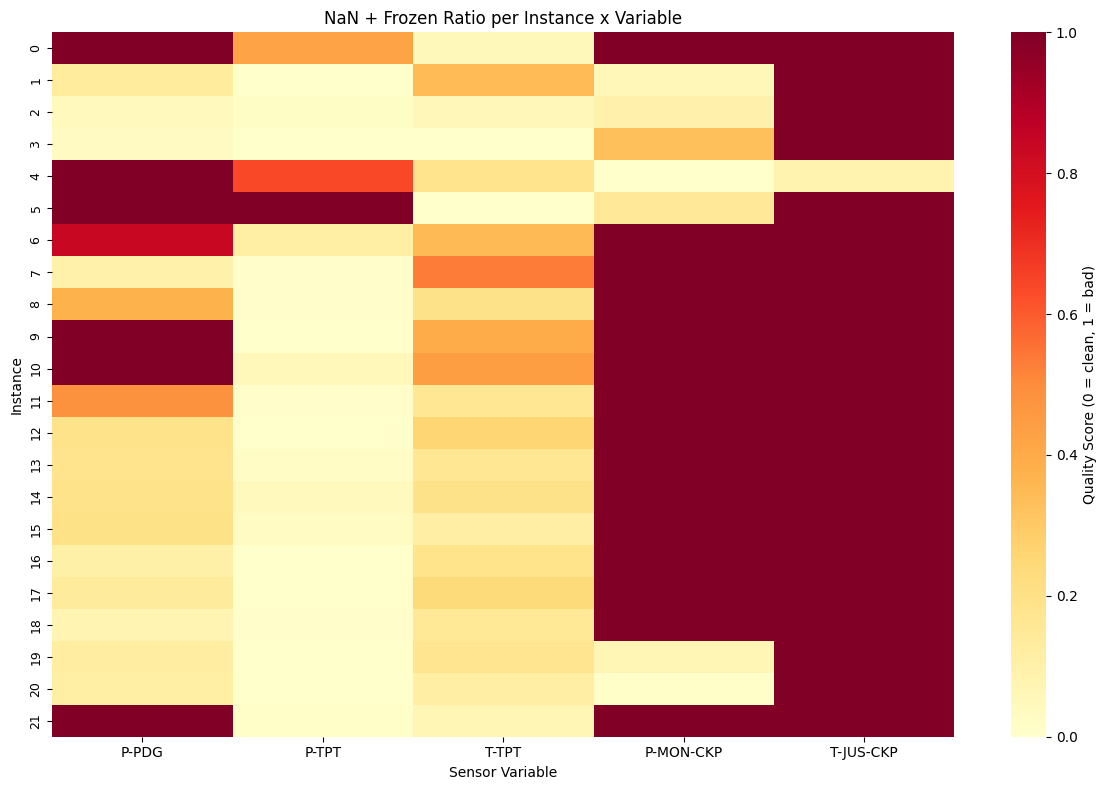

In [3]:
import numpy as np
import pandas as pd

instance_labels = [str(i) for i in range(len(ds))]

viz = DataQualityHeatmap.from_data_map(
    data_map,
    variables=TARGET_VARS,
    instance_labels=instance_labels,
)
fig, ax = viz.plot()
plt.show()

## 2. Univariate Processing Pipeline

For each sensor variable we build an `sklearn.Pipeline` with five steps:

1. **Quality Control** — discard instances with too many NaNs or frozen values; interpolate minor gaps.
2. **Resampling** — downsample to speed up DTW (O(N²) complexity).
3. **Scaling** — Z-normalize each instance to focus on shape, not amplitude.
4. **Distance Matrix** — compute pairwise DTW distances.
5. **Hierarchical Clustering** — build the linkage tree.

In [4]:
trained_models = {}
valid_indices_map = {}
cleaned_data_map = {}

for var_name in TARGET_VARS:
    series_list = data_map[var_name]
    print(f"Processing {var_name}...", end=" ", flush=True)

    try:
        # Step 1: Quality filter (applied separately to track kept_indices_)
        qc = InstanceQualityFilter(
            InstanceQualityConfig(max_nan_ratio=0.2, max_frozen_ratio=0.95)
        )
        X_clean = qc.fit_transform(series_list)

        if len(X_clean) == 0:
            print("Skipped (all instances removed)")
            continue

        # Steps 2-5: sklearn Pipeline
        pipe = Pipeline([
            ("resample", TimeSeriesResampler(ResamplingConfig(step_size=100, step_method="slice"))),
            ("scaler", TimeSeriesScaler(TimeSeriesScalingConfig())),
            ("dtw", DistanceComputer(DistanceMatrixConfig(metric=DistanceMetricEnum.DTW, n_jobs=-1))),
            ("clusterer", HierarchicalClusterer(HierarchicalClusteringConfig())),
        ])
        pipe.fit(X_clean)

        # Store results
        trained_models[var_name] = pipe.named_steps["clusterer"]
        valid_indices_map[var_name] = qc.kept_indices_

        # Store processed series for overlay visualization later
        resampled = pipe.named_steps["resample"].transform(X_clean)
        scaled = pipe.named_steps["scaler"].transform(resampled)
        cleaned_data_map[var_name] = scaled

        print(f"Kept {len(qc.kept_indices_)} instances")

    except Exception as e:
        print(f"Error: {e}")

print(f"\nSuccessfully processed {len(trained_models)} variables: {list(trained_models.keys())}")

Processing P-PDG... Kept 16 instances
Processing P-TPT... Kept 21 instances
Processing T-TPT... Kept 22 instances
Processing P-MON-CKP... Kept 7 instances
Processing T-JUS-CKP... Error: The number of observations cannot be determined on an empty distance matrix.

Successfully processed 4 variables: ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP']


### 2.1 Dendrogram Visualization

Inspect the hierarchical tree for each variable. The dashed red line shows the default threshold cut.

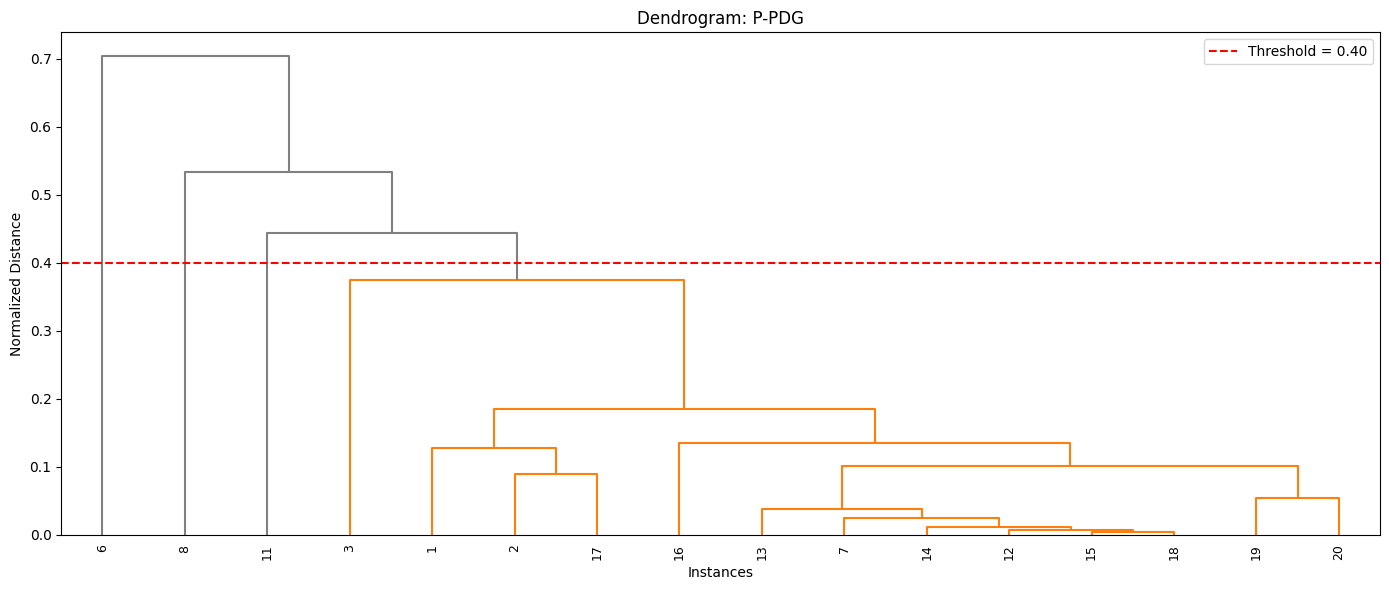

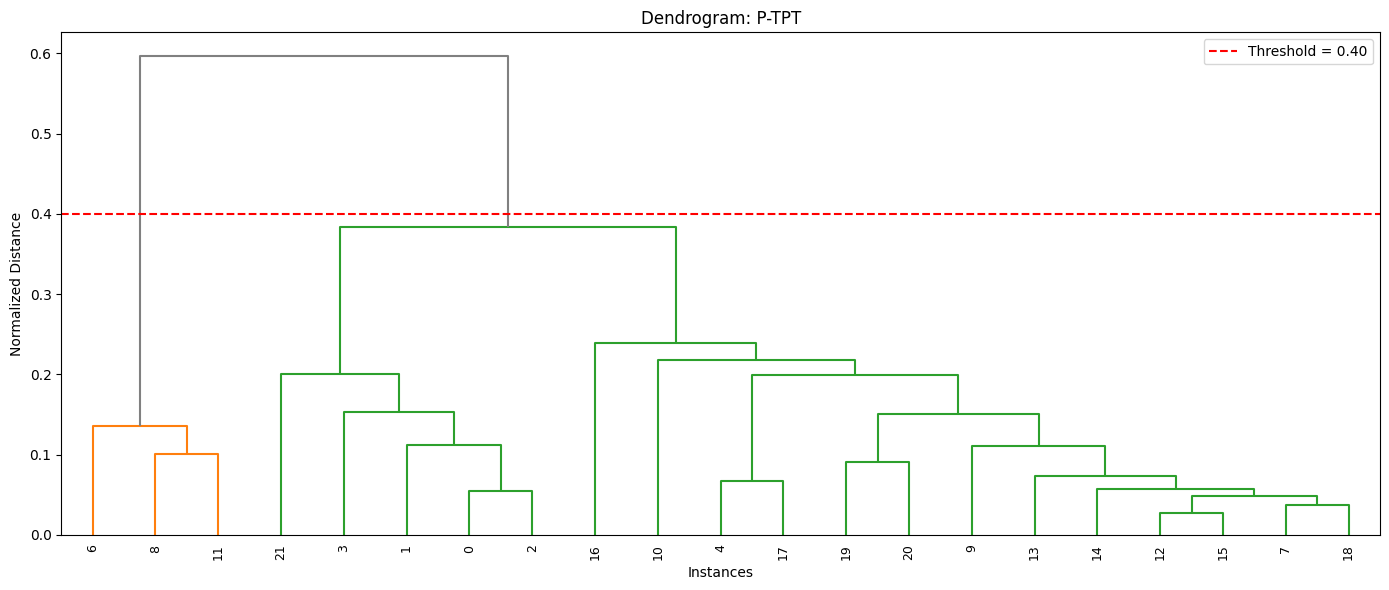

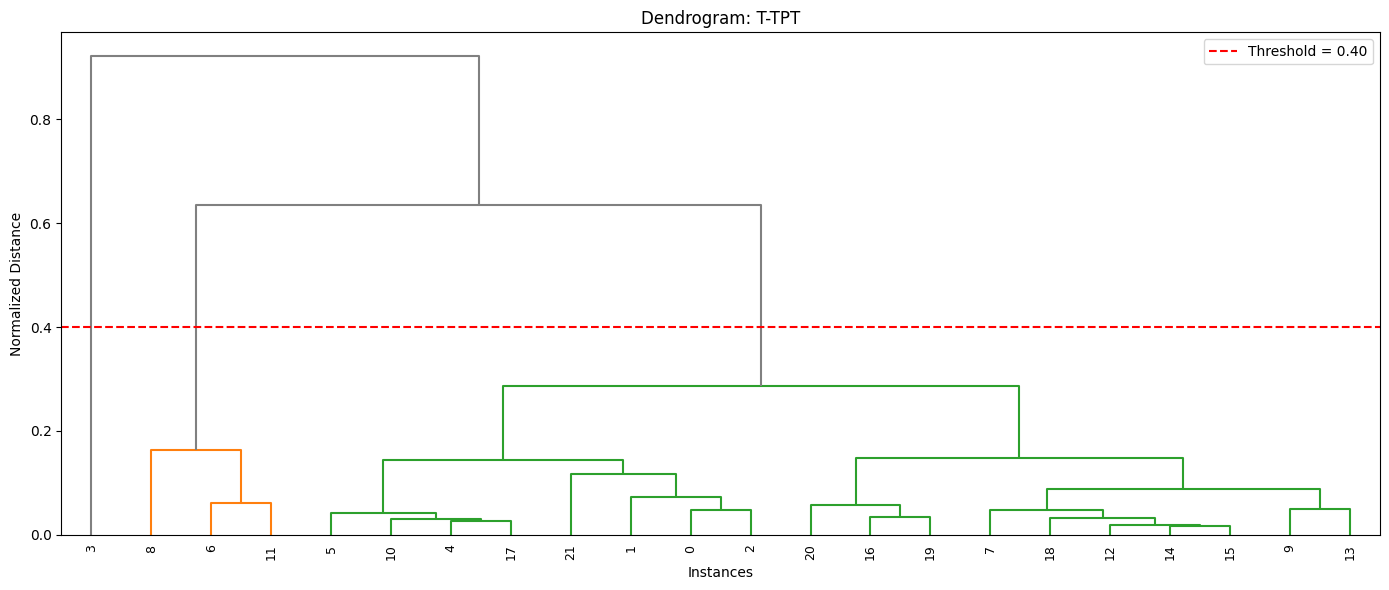

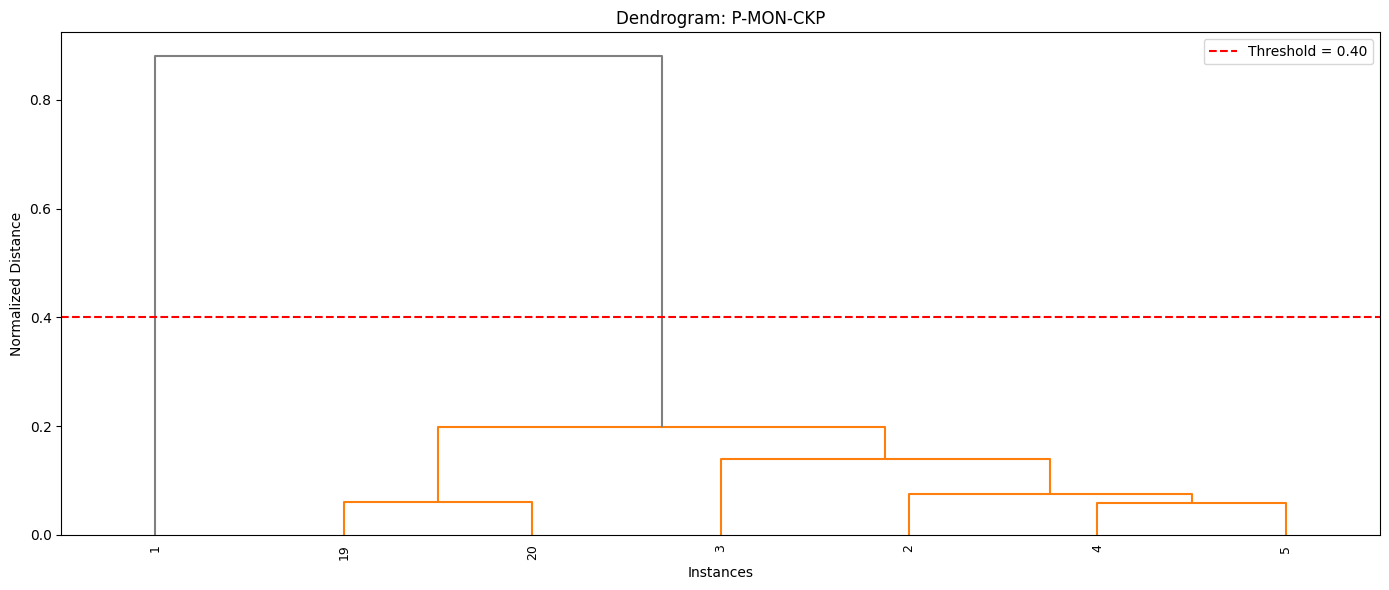

In [5]:
valid_vars = list(trained_models.keys())

for var in valid_vars:
    model = trained_models[var]
    viz = DendrogramPlot(
        model.linkage_matrix_,
        threshold=0.4,
        title=f"Dendrogram: {var}",
        show_instance_indices=True,
        instance_indices=valid_indices_map[var],
    )
    fig, ax = viz.plot()
    plt.show()

### 2.2 Cluster Stability Analysis

How does the size of the main cluster change as we relax the distance threshold?

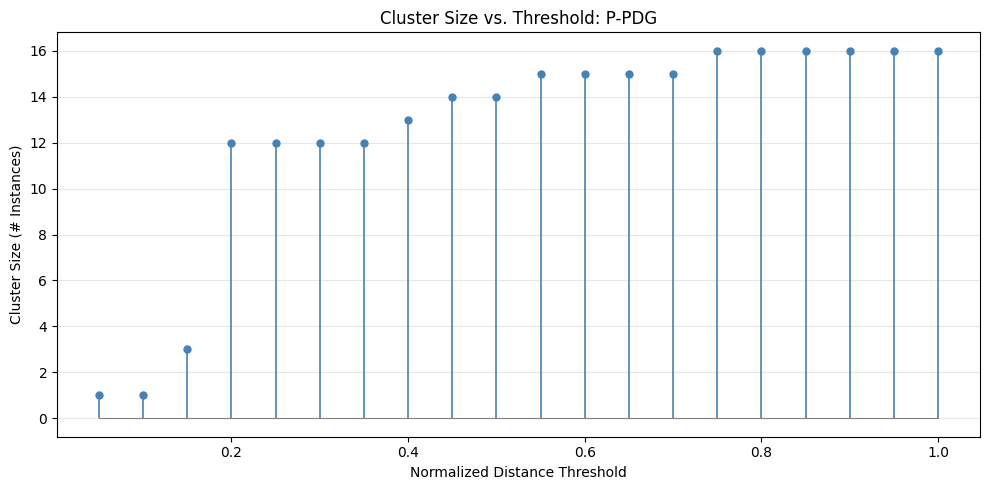

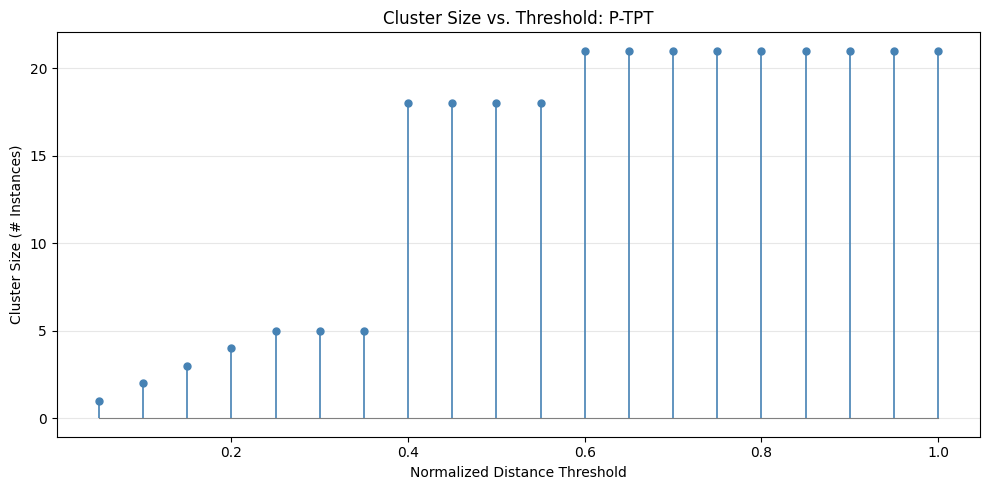

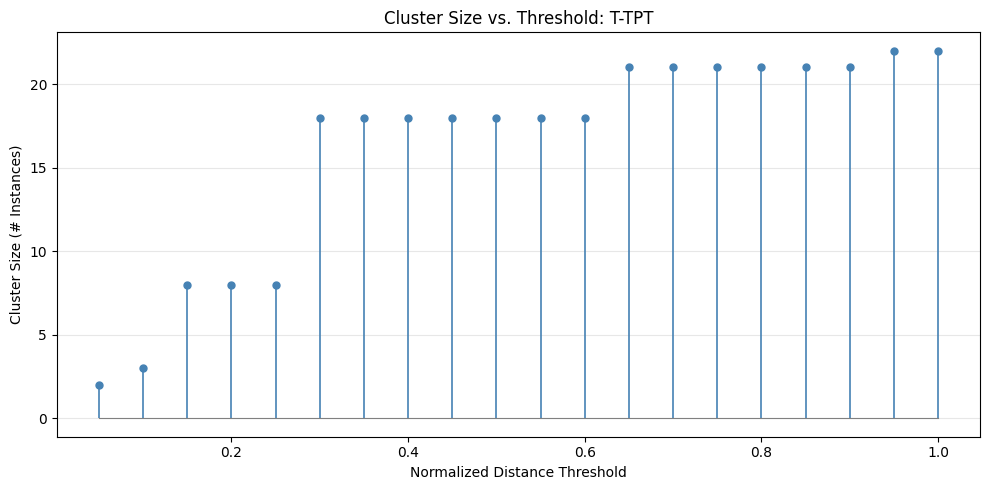

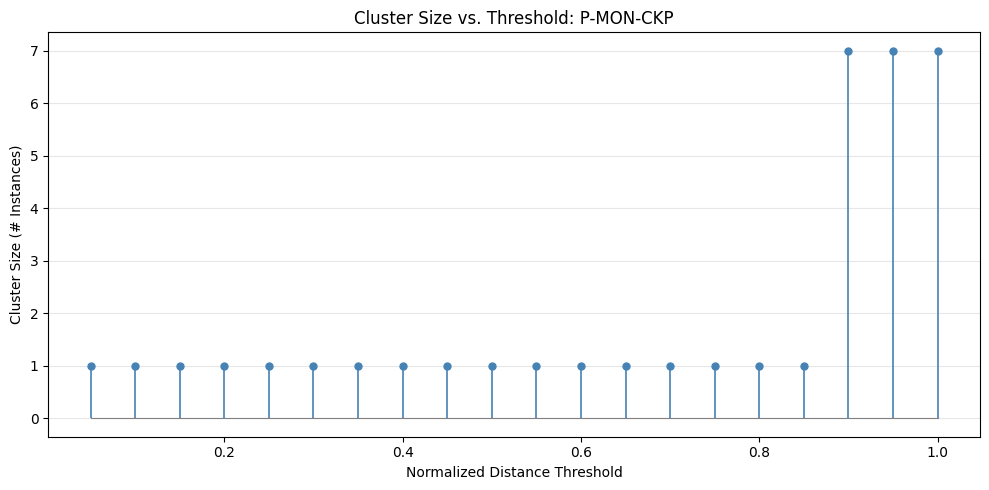

In [6]:
# Compute cluster size at each threshold for each variable
thresholds = np.arange(0.05, 1.05, 0.05).tolist()

for var in valid_vars:
    model = trained_models[var]
    counts = {t: len(model.find_main_cluster_indices(t)) for t in thresholds}
    viz = ClusterSizeCurvePlot(counts, title=f"Cluster Size vs. Threshold: {var}")
    fig, ax = viz.plot()
    plt.show()

In [13]:
vars_to_exclude = ['P-MON-CKP']

for var in vars_to_exclude:
    del trained_models[var]
    del valid_indices_map[var]
    valid_vars.remove(var)
    #num_vars -= 1

print(f"Remaining variables: {list(trained_models.keys())}")

KeyError: 'P-MON-CKP'

## 3. Multivariate Consensus

`MultivariateConsensus` sweeps across distance thresholds and intersects the per-variable cluster memberships. An instance only survives at threshold T if it belongs to the main cluster for **every** variable at that threshold.

In [14]:
consensus = MultivariateConsensus(MultivariateConsensusConfig(
    min_threshold=0.05,
    max_threshold=1.0,
    threshold_step=0.05,
))
consensus.fit(trained_models, valid_indices_map=valid_indices_map)

print("Consensus counts per threshold:")
for t, count in consensus.common_counts_.items():
    print(f"  t={t:.2f}: {count} instances")

Consensus counts per threshold:
  t=0.05: 0 instances
  t=0.10: 0 instances
  t=0.16: 2 instances
  t=0.21: 2 instances
  t=0.26: 2 instances
  t=0.31: 2 instances
  t=0.37: 2 instances
  t=0.42: 12 instances
  t=0.47: 12 instances
  t=0.53: 12 instances
  t=0.58: 12 instances
  t=0.63: 12 instances
  t=0.68: 14 instances
  t=0.74: 15 instances
  t=0.79: 15 instances
  t=0.84: 15 instances
  t=0.89: 15 instances
  t=0.95: 16 instances
  t=1.00: 16 instances


## 4. Visualization

### 4.1 Selection Heatmap

Binary heatmap: rows are thresholds, columns are instances. A filled cell means the instance survived consensus at that threshold.

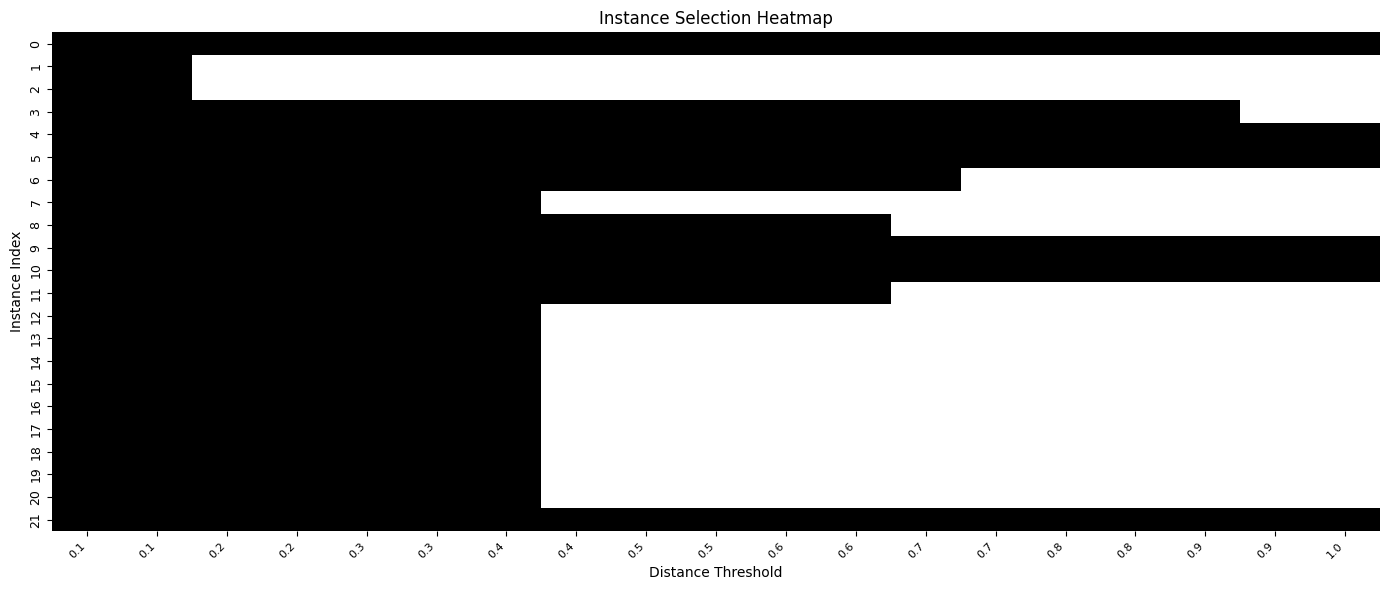

In [15]:
viz = SelectionHeatmapPlot(
    consensus.selection_mask_,
    consensus.thresholds_analyzed_,
)
fig, ax = viz.plot()
plt.show()

### 4.2 Consensus Cluster Size Curve

The same threshold sweep, but now showing the **consensus** count (instances surviving across all variables simultaneously).

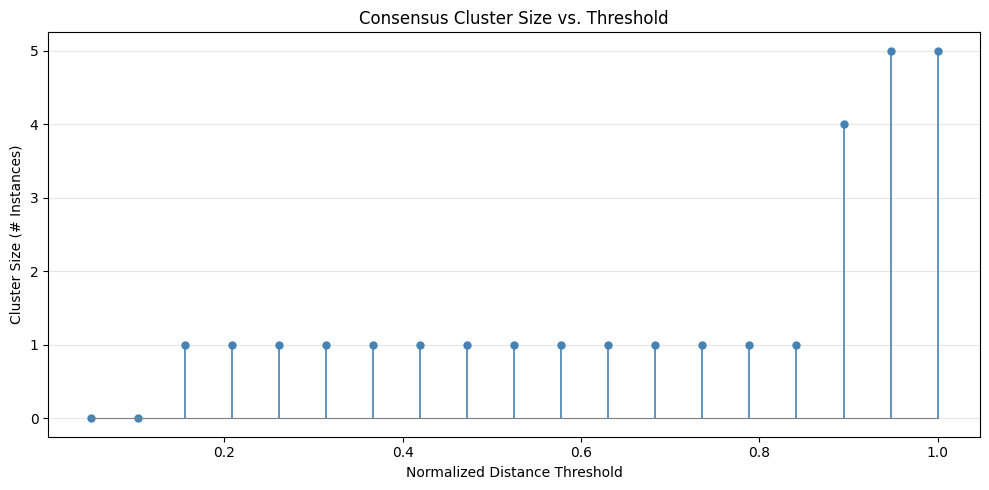

In [9]:
viz = ClusterSizeCurvePlot(
    consensus.common_counts_,
    title="Consensus Cluster Size vs. Threshold",
)
fig, ax = viz.plot()
plt.show()

### 4.3 Time Series Clustering Overlay

Overlay plot per variable. **Blue** = selected (consensus), **gray** = rejected. Pick a threshold to decide which instances are "well-behaved".

Selected 1 instances at threshold 0.4


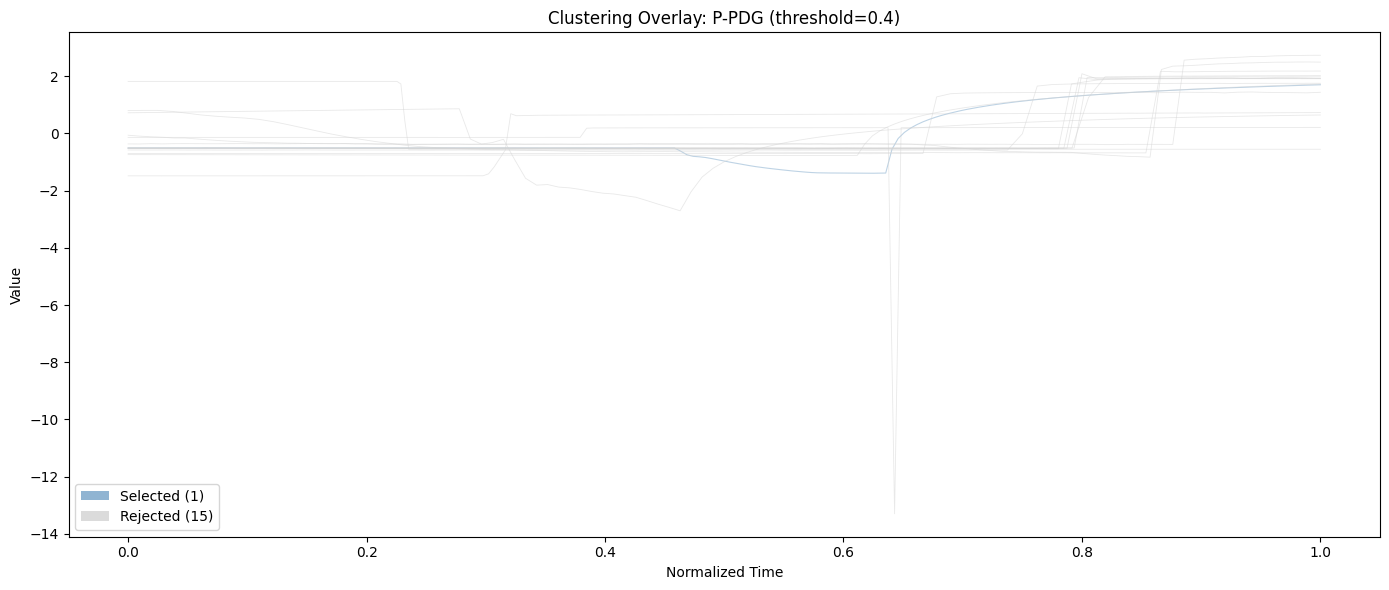

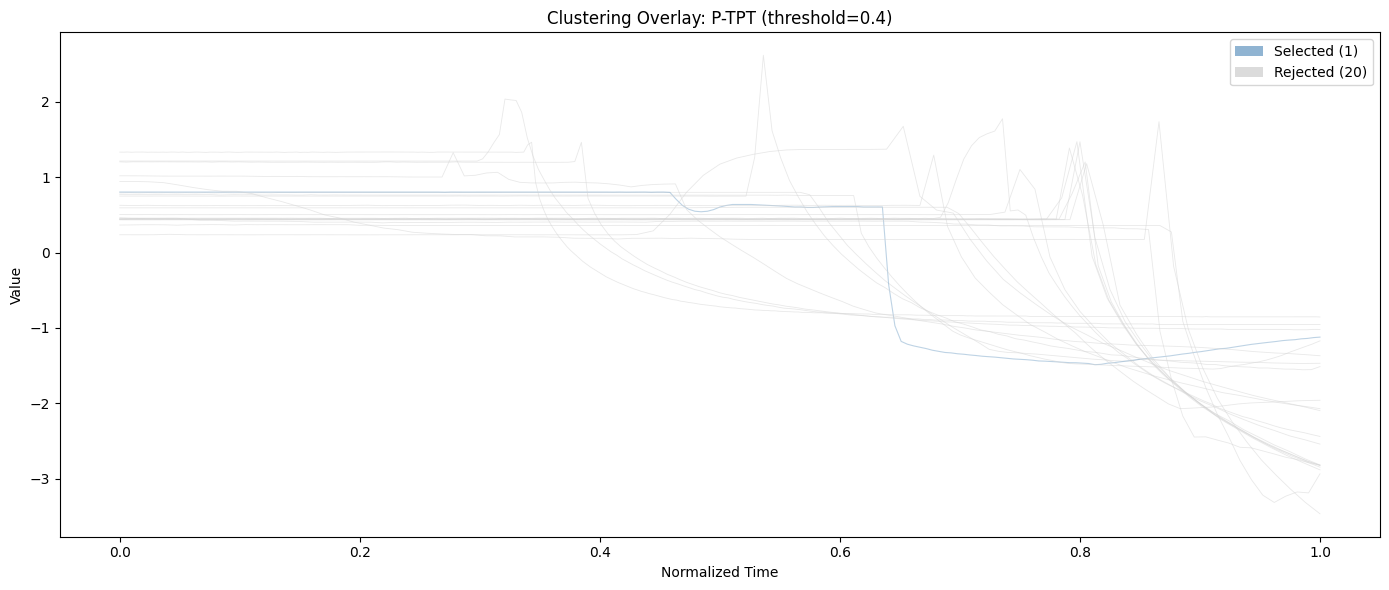

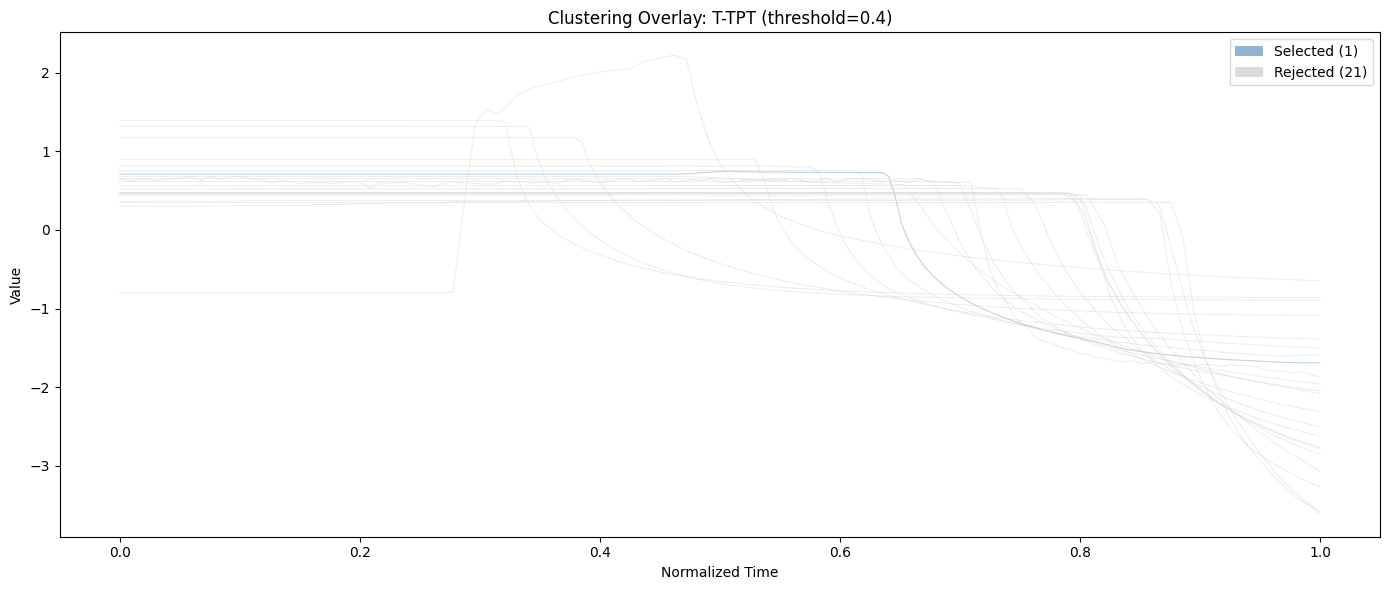

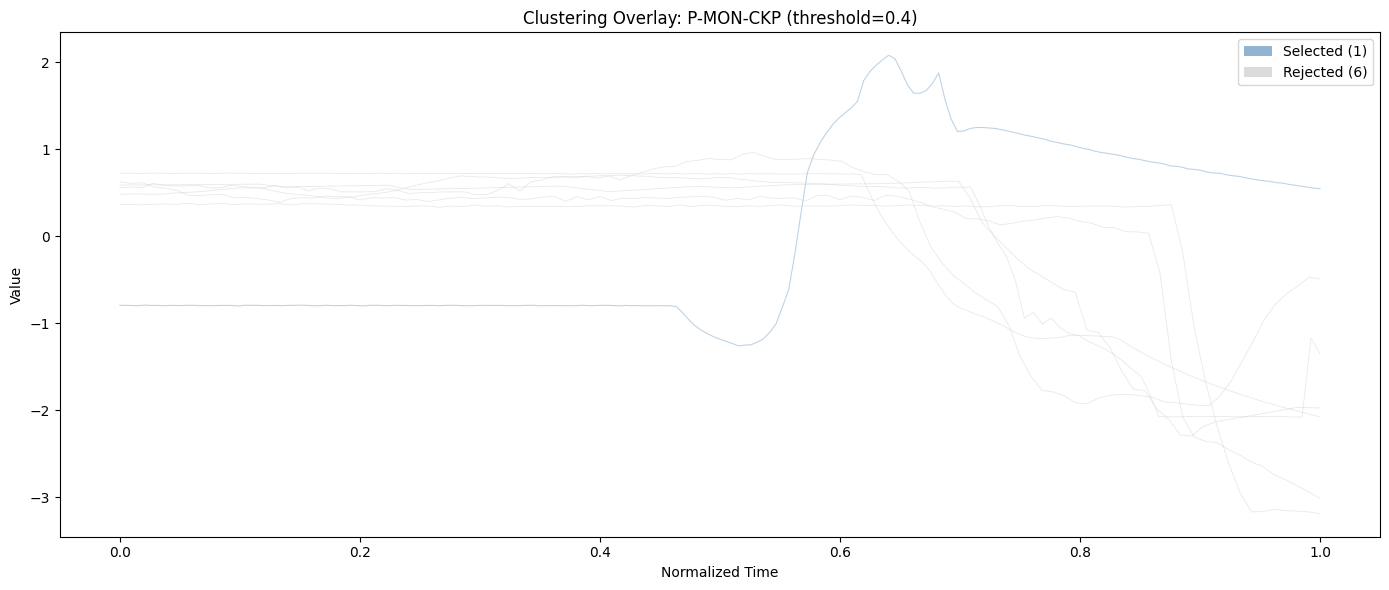

In [10]:
CONSENSUS_THRESHOLD = 0.4
selected_global = consensus.get_selected_indices_at_threshold(CONSENSUS_THRESHOLD)
print(f"Selected {len(selected_global)} instances at threshold {CONSENSUS_THRESHOLD}")

for var in valid_vars:
    local_mapping = valid_indices_map[var]
    series_data = cleaned_data_map[var]

    # Map global selection to local indices
    local_selection = [
        local_mapping.index(g) for g in selected_global if g in local_mapping
    ]

    viz = ClusteringOverlayPlot(
        series_data,
        local_selection,
        title=f"Clustering Overlay: {var} (threshold={CONSENSUS_THRESHOLD})",
    )
    fig, ax = viz.plot()
    plt.show()

### 4.4 Ranked Distance Plot

Bar chart showing the elimination distance from the `DivisiveRanker` perspective. We fit a `DivisiveRanker` on each variable's distance matrix to rank instances from most outlier (left) to tightest centroid (right), then color them by consensus status.

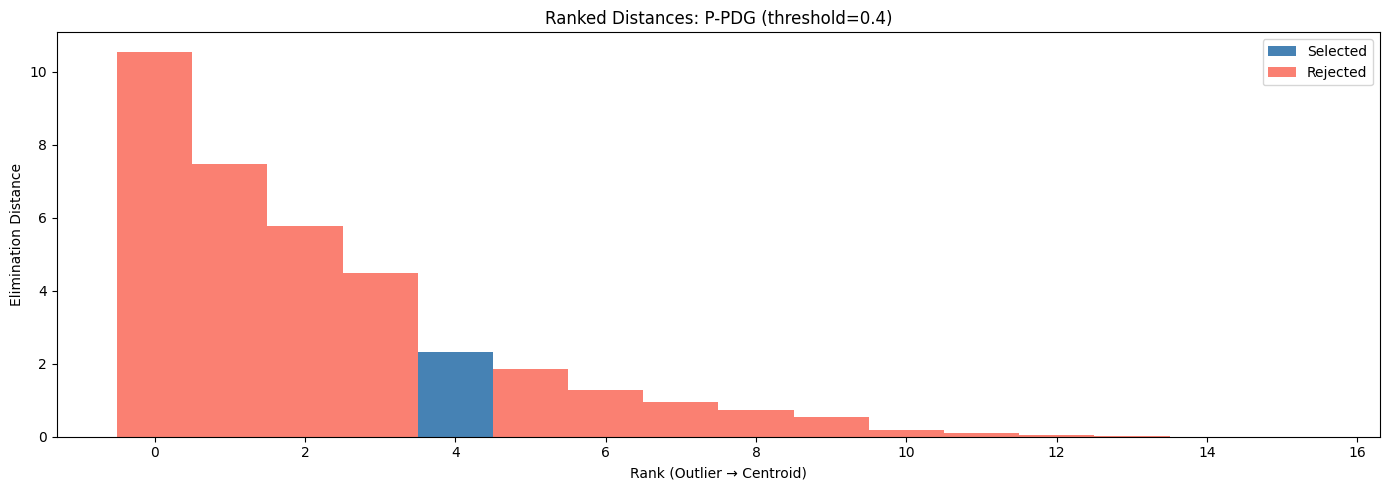

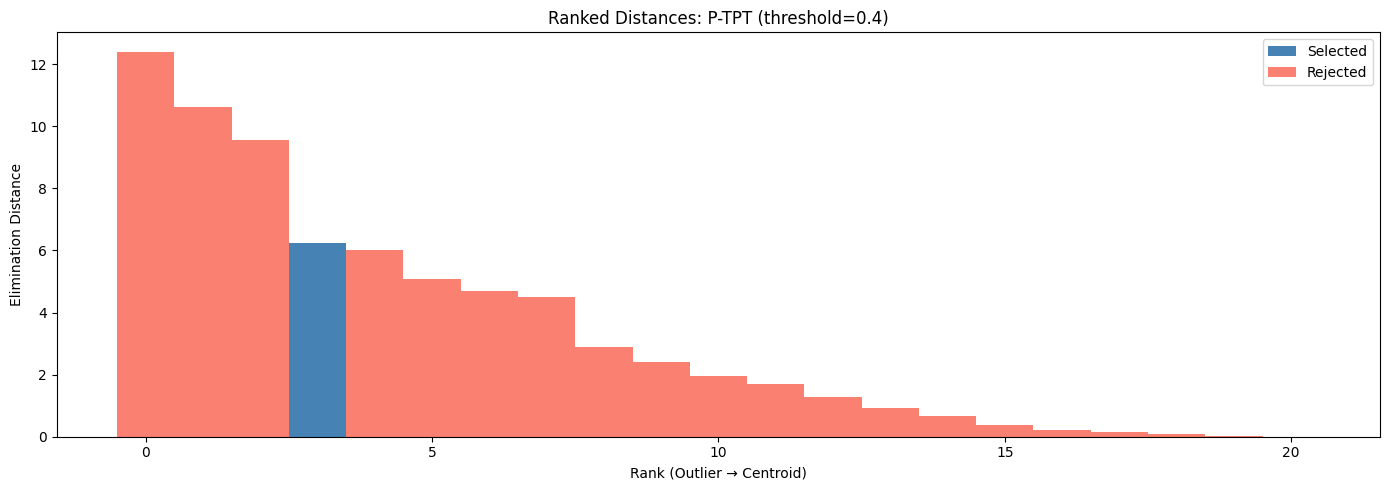

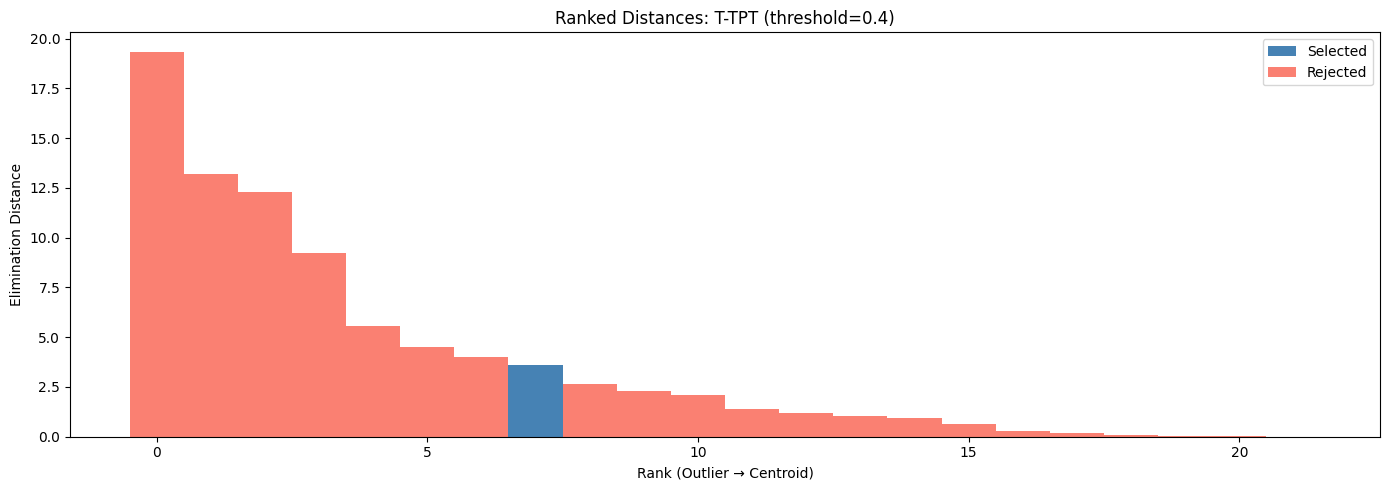

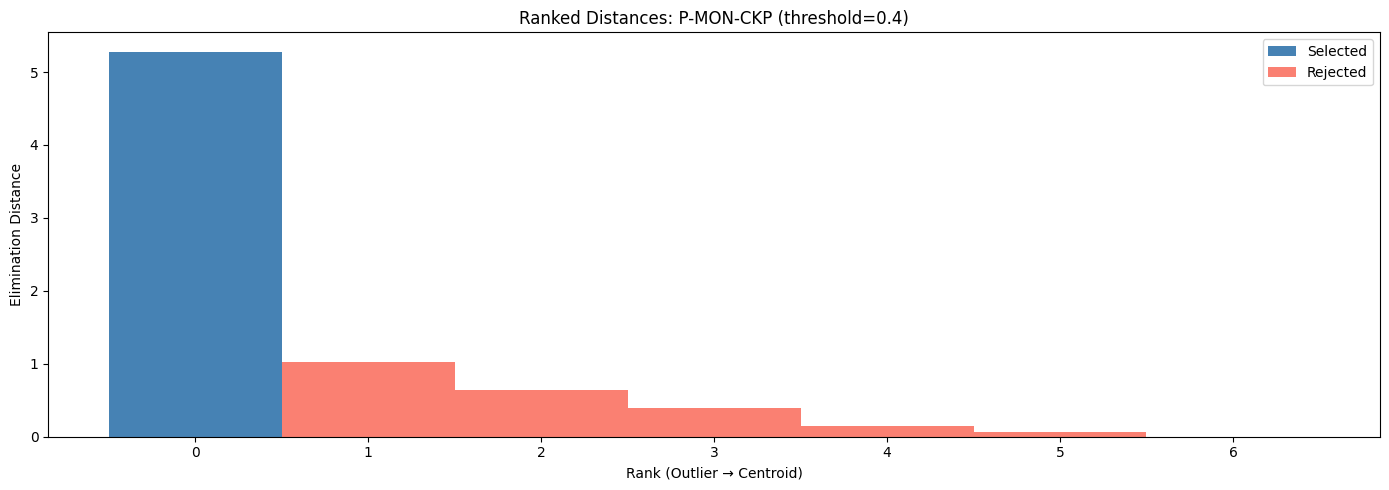

In [11]:
from ThreeWToolkit.clustering import DivisiveRanker
from ThreeWToolkit.core.base_clustering import DivisiveClusteringConfig

for var in valid_vars:
    model = trained_models[var]
    local_mapping = valid_indices_map[var]

    # Map global selection to local indices
    local_selection = [
        local_mapping.index(g) for g in selected_global if g in local_mapping
    ]

    # Fit divisive ranker on the normalized distance matrix
    ranker = DivisiveRanker(DivisiveClusteringConfig())
    ranker.fit(model.distance_matrix_normalized_)

    viz = RankedDistancePlot(
        ranker.ranking_,
        ranker.elimination_distances_,
        local_selection,
        title=f"Ranked Distances: {var} (threshold={CONSENSUS_THRESHOLD})",
    )
    fig, ax = viz.plot()
    plt.show()